# Differentiation methods for probabilistic circuits


In [1]:
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from torx import (
    DiscretePCircuit,
    draw_circuit,
    PCNOT,
    PNOT,
    SampleSimulator,
    StateVectorSimulator,
)
from tqdm import tqdm

Parameter shift inf (version 1):

$$\frac{\partial U(\theta)}{\partial\theta}=\left[U(\infty)-U(-\infty)\right]\sigma(\theta)(1-\sigma(\theta))$$

Parameter shift single (version 2):

$$\frac{\partial U(\theta)}{\partial\theta}=U(\theta)-U\left(-\ln\left(\left(1+e^{-\theta}\right)^2-1\right)\right)$$

Adjoint: (work in progress)

We consider the following toy circuit and the three differentiation methods above, as well as the exact gradient via state vector simulation:

In [2]:
rng = np.random.default_rng(100)
key = jax.random.key(1003)

params = jnp.array(rng.uniform(-1, 1, size=12))
circuit = DiscretePCircuit(
    [
        PNOT(params[0], 0),
        PNOT(params[1], 1),
        PNOT(params[2], 2),
        PCNOT(params[3], [0, 1]),
        PCNOT(params[4], [1, 2]),
        PCNOT(params[5], [2, 0]),
        PNOT(params[6], 0),
        PNOT(params[7], 1),
        PNOT(params[8], 2),
        PCNOT(params[9], [0, 1]),
        PCNOT(params[10], [1, 2]),
        PCNOT(params[11], [2, 0]),
    ]
)
draw_circuit(circuit)
sim_sv = StateVectorSimulator()
sim_ps1 = SampleSimulator(num_samples=10000, diff_method="param_shift_inf")
sim_ps2 = SampleSimulator(num_samples=10000, diff_method="param_shift_single")
sim_ps3 = SampleSimulator(num_samples=10000, diff_method="param_shift_filter")
# sim_adj = SampleSimulator(diff_method="adjoint")

compiled_circuit = SampleSimulator.build_circuit(circuit)

     ┌──────┐                  ┌───────┐┌──────┐                  ┌───────┐  
p_0: ┤ PNOT ├────■─────────────┤ PCNOT ├┤ PNOT ├────■─────────────┤ PCNOT ├──
     └──────┘    │             └───┬───┘└──────┘    │             └───┬───┘  
     ┌──────┐┌───┴───┐             │    ┌──────┐┌───┴───┐             │      
p_1: ┤ PNOT ├┤ PCNOT ├────■────────│────┤ PNOT ├┤ PCNOT ├────■────────│──────
     └──────┘└───────┘    │        │    └──────┘└───────┘    │        │      
     ┌──────┐         ┌───┴───┐    │    ┌──────┐         ┌───┴───┐    │      
p_2: ┤ PNOT ├─────────┤ PCNOT ├────■────┤ PNOT ├─────────┤ PCNOT ├────■──────
     └──────┘         └───────┘         └──────┘         └───────┘           


Suppose we want to calculate the gradient of the probability of measuring $1$ on the last pbit. First we verify that all 4 methods produce the same probability, up to shot noise:

In [3]:
initial_sv = jnp.zeros(8).at[0].set(1)
initial_basis = jnp.array([0.0, 0.0, 0.0])

expval_sv = sim_sv.expval(circuit, initial_sv, pbit=2)
expval_ps1 = sim_ps1.expval(compiled_circuit, initial_basis, pbit=2, key=key)
expval_ps2 = sim_ps2.expval(compiled_circuit, initial_basis, pbit=2, key=key)
expval_ps3 = sim_ps3.expval(compiled_circuit, initial_basis, pbit=2, key=key)
# n = 10000
# expval_adj = sim_adj.expval(circuit, initial_basis, pbit=2, key=key, num_samples=n)

print(expval_sv)
print(expval_ps1)
print(expval_ps2)
print(expval_ps3)
# print(expval_adj)

0.49870765
0.49769998
0.49769998
0.49769998


In [4]:
grad_sv = eqx.filter_jit(eqx.filter_grad(sim_sv.expval))(circuit, initial_sv, pbit=2)

Two more metrics of interest are the variances of the probability and the runtime of the gradient calculation. We're looking for lower variances since there would be less noise in the gradient and thus in the optimization loop, and we're also looking for smaller runtimes. We can measure both of these by running the gradient calculation many times and computing the variance and average runtimes.

Note that there is zero variance in the exact state vector gradient, so we skip this.

In [5]:
grads_ps1 = []
n = 50
for i in tqdm(range(n)):
    if i == 2:
        start = time.time()

    grad_ps1 = jax.block_until_ready(
        eqx.filter_jit(eqx.filter_grad(sim_ps1.expval))(
            compiled_circuit, initial_basis, pbit=2, key=jax.random.key(i + 1000)
        )
    )
    grads_ps1.append(np.asarray(jnp.stack(jax.tree.leaves(grad_ps1))).squeeze())

time_ps1 = (time.time() - start) / (n - 2)

grads_ps2 = []
for i in tqdm(range(n)):
    if i == 2:
        start = time.time()

    grad_ps2 = jax.block_until_ready(
        eqx.filter_jit(eqx.filter_grad(sim_ps2.expval))(
            compiled_circuit, initial_basis, pbit=2, key=jax.random.key(i + 1000)
        )
    )
    grads_ps2.append(np.asarray(jnp.stack(jax.tree.leaves(grad_ps2))).squeeze())

time_ps2 = (time.time() - start) / (n - 2)

grads_ps3 = []
for i in tqdm(range(n)):
    if i == 2:
        start = time.time()

    grad_ps3 = jax.block_until_ready(
        eqx.filter_jit(eqx.filter_grad(sim_ps3.expval))(
            compiled_circuit, initial_basis, pbit=2, key=jax.random.key(i + 1000)
        )
    )
    grads_ps3.append(np.asarray(jnp.stack(jax.tree.leaves(grad_ps3))).squeeze())

time_ps3 = (time.time() - start) / (n - 2)

100%|██████████| 50/50 [00:01<00:00, 45.60it/s]


Plot the variance results:

(50, 12)


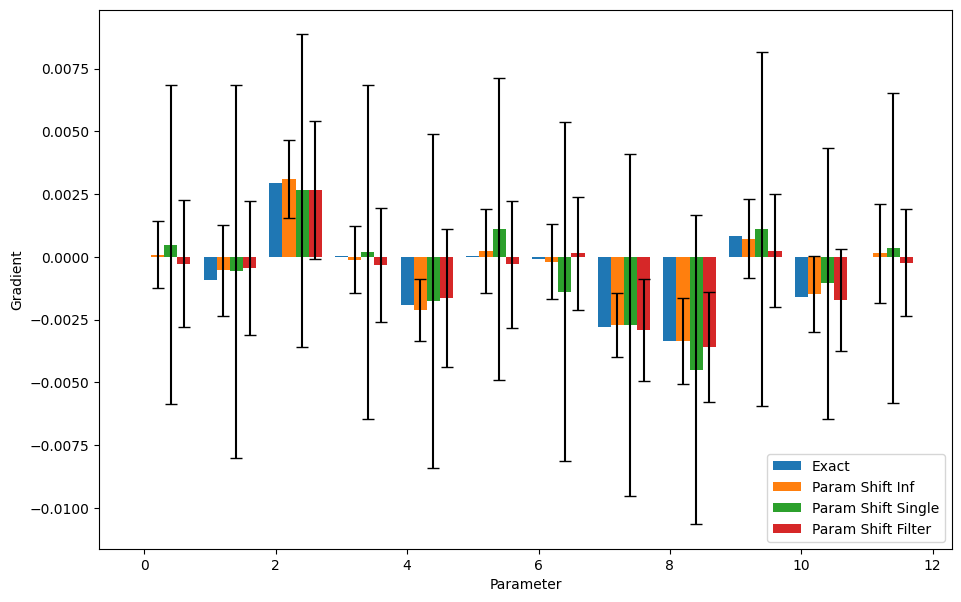

In [6]:
grads_ps1 = np.asarray(grads_ps1)
grads_ps2 = np.asarray(grads_ps2)
grads_ps3 = np.asarray(grads_ps3)

print(grads_ps1.shape)

exact_grads = np.asarray(jnp.stack(jax.tree.leaves(grad_sv))).squeeze()

fig, ax = plt.subplots(1, 1, figsize=(11, 7))
plt.bar(
    np.arange(grads_ps1.shape[1]),
    exact_grads,
    width=0.2,
    label="Exact",
)
plt.bar(
    np.arange(grads_ps1.shape[1]) + 0.2,
    np.mean(grads_ps1, axis=0),
    width=0.2,
    yerr=np.std(grads_ps1, axis=0),
    capsize=4,
    label="Param Shift Inf",
)
plt.bar(
    np.arange(grads_ps1.shape[1]) + 0.4,
    np.mean(grads_ps2, axis=0),
    width=0.2,
    yerr=np.std(grads_ps2, axis=0),
    capsize=4,
    label="Param Shift Single",
)
plt.bar(
    np.arange(grads_ps1.shape[1]) + 0.6,
    np.mean(grads_ps3, axis=0),
    width=0.2,
    yerr=np.std(grads_ps3, axis=0),
    capsize=4,
    label="Param Shift Filter",
)
plt.legend(loc="best")
plt.xlabel("Parameter")
plt.ylabel("Gradient")
plt.show()

See the runtimes:

In [7]:
print(f"Time per loop (Param Shift Inf): {time_ps1}")
print(f"Time per loop (Param Shift Single): {time_ps2}")
print(f"Time per loop (Param Shift Filter): {time_ps3}")
# print(f'Time per loop (adjoint): {time_adj}')

Time per loop (Param Shift Inf): 0.001299247145652771
Time per loop (Param Shift Single): 0.0013620257377624512
Time per loop (Param Shift Filter): 0.0011983166138331096


A few points of interest:

1.  The variance of the parameter shift v2 differentiation method is higher than the parameter shift v1. This is possibly due to the fact that v1 has only deterministic gates in the shifted parameters.
2.  The variances of the parameter shift v1 and the adjoint methods are very similar
3.  The runtime of parameter shift v1 is the largest, followed by parameter shift v2, followed by adjoint. This is because v1 needs $2N$ circuit evaluations to compute gradients for all parameters, v2 needs $N$ circuit evaluations, and the adjoint method needs only $1$ evaluation.